# ZeRO-0/1/2/3 on 32 virtual GPUs

Built as ERA V5 Session 12 assignment. "The notes" below are that session's course notes, which supply the 16-byte table and the 30B memory ladder I compare against.

**What is being simulated.** 32 virtual GPUs (ranks 0 to 31) train one small GPT together with data parallelism. Each virtual GPU is a Python object that owns real tensors: bf16 weights, bf16 gradients, fp32 master weights, Adam `m` and Adam `v`, exactly the 2 + 2 + 4 + 4 + 4 = 16 bytes per parameter from the notes. The ZeRO stage decides which of those five tensors a rank keeps in full and which it keeps as a 1/32 shard.

The ranks run in lockstep, one model unit at a time, and they talk only through ring collectives (reduce-scatter, all-gather, all-reduce) that log every send. Nothing here needs a GPU.

**What the notebook checks.**
1. what each rank stores under each stage, read off the actual tensors
2. that measured bytes per rank equal the course formulas
3. that reduce-scatter followed by all-gather equals all-reduce, on real gradients
4. that DP, ZeRO-1, ZeRO-2 and ZeRO-3 produce the same weight update
5. what changes in model compute, optimizer work and communication
6. the same accounting scaled to the 30B model from the notes

In [1]:
import gc, json, math, platform, time
from pathlib import Path

import numpy as np
import pandas as pd
import psutil
import torch
import matplotlib
import matplotlib.pyplot as plt

from zero_sim.model import GPTConfig, build_layout, init_flat_params
from zero_sim.cluster import (CATEGORIES, BYTES, SHARDED, STAGE_NAMES, make_cluster, owned_param_slices)
from zero_sim.collectives import (CommLog, ring_reduce_scatter, ring_all_gather, ring_all_reduce, naive_all_reduce)
from zero_sim.engine import OptConfig, make_batches, run_stage, run_single_device, local_gradients
from zero_sim.accounting import (GIB, CARD_GIB, COURSE_BYTES_PER_PARAM_8GPU, COURSE_LADDER_30B_GIB, COURSE_COMM_P,
                                 course_bytes_per_param, measured_bytes_per_param, measured_rank_bytes,
                                 held_fraction, project_gib_per_gpu, ring_comm_P)
from zero_sim import plots

pd.set_option("display.width", 160); pd.set_option("display.max_columns", 20)
torch.manual_seed(0)
T_START = time.perf_counter()
RES, FIG = Path("results"), Path("figures")
RES.mkdir(exist_ok=True); FIG.mkdir(exist_ok=True)
CHECKS = []                                  # every assertion below is also recorded here
def check(name, ok, detail=""):
    CHECKS.append(dict(check=name, passed=bool(ok), detail=str(detail)))
    assert ok, f"{name}: {detail}"

WORLD, RANK = 32, 11                         # rank 11: an ordinary middle rank, nothing special like rank 0
STEPS, MICRO_BS = 3, 2
print("python", platform.python_version(), "| torch", torch.__version__, "| CPU:", platform.processor())
print(f"RAM {psutil.virtual_memory().total / GIB:.1f} GiB total, {psutil.virtual_memory().available / GIB:.2f} GiB available")

python 3.14.4 | torch 2.14.0+cpu | CPU: Intel64 Family 6 Model 140 Stepping 1, GenuineIntel
RAM 7.8 GiB total, 0.51 GiB available


## 1. The demo model

A 4-layer GPT with byte-level tokens. It is written as six **units** (embedding, four blocks, final norm + head). Each unit's parameters live in one flat vector. That flat vector is what gets sharded, gathered and reduced, so "rank 11's shard of block 2" is simply a contiguous index range.

I sized the model from the laptop's memory rather than picking a round number. Data parallelism here really allocates 32 full copies of the 16-byte state, so the DP run needs 32 x 16 B x P of RAM. At 0.87M parameters that is 444 MB (423 MiB). This laptop has 7.8 GiB and very little of it free, so I did not want to go higher. Section 10 prints the process's peak working set.

In [2]:
cfg, opt = GPTConfig(), OptConfig()
layout = build_layout(cfg)
P = sum(u.numel for u in layout)
check("parameter count", P == 867_072, P)
units = pd.DataFrame([dict(unit=u.name, tensors=len(u.entries), params=u.numel, share=f"{u.numel / P:.1%}",
                           elements_per_rank_shard=u.numel // WORLD, divides_by_32=u.numel % WORLD == 0) for u in layout])
print(cfg); print(opt)
print(f"total parameters P = {P:,}   |   16-bit copy of the weights = {2 * P:,} bytes ({2 * P / 2**20:.3f} MiB)")
units

GPTConfig(vocab_size=256, block_size=64, n_layer=4, n_head=4, d_model=128)
OptConfig(lr=0.001, beta1=0.9, beta2=0.95, eps=1e-08, clip=1.0)
total parameters P = 867,072   |   16-bit copy of the weights = 1,734,144 bytes (1.654 MiB)


,unit,tensors,params,share,elements_per_rank_shard,divides_by_32
0,embed,2,40960,4.7%,1280,True
1,block0,12,198272,22.9%,6196,True
2,block1,12,198272,22.9%,6196,True
3,block2,12,198272,22.9%,6196,True
4,block3,12,198272,22.9%,6196,True
5,head,3,33024,3.8%,1032,True


## 2. Thirty-two virtual GPUs and what each one owns

A `VirtualGPU` has a `rank`, a `persistent` dict of tensors that survive between steps, and a separate ledger for temporary buffers. The stage controls one thing: which categories are sharded.

| stage | sharded across the 32 ranks | still a full replica on every rank |
|---|---|---|
| DP (ZeRO-0) | nothing | weights, grads, master, m, v |
| ZeRO-1 | master, m, v | weights, grads |
| ZeRO-2 | grads, master, m, v | weights |
| ZeRO-3 | everything | nothing |

Below, the ranks are built for each stage and rank 11 is asked what it holds. The numbers are `tensor.numel()` and `tensor.nbytes` of the tensors in its dict. The clusters here are built on PyTorch's `meta` device (shapes and dtypes, no storage); the real runs later build the same objects with real storage, and section 10 checks that both give identical bytes.

In [3]:
meta = {st: make_cluster(st, WORLD, layout, device="meta") for st in range(4)}
check("32 ranks per stage", all(len(meta[st]) == 32 and [g.rank for g in meta[st]] == list(range(32)) for st in range(4)))
rows = []
for st in range(4):
    for r in meta[st][RANK].describe():
        rows.append(dict(stage=STAGE_NAMES[st], **r))
own = pd.DataFrame(rows)
own_pivot = own.pivot(index="category", columns="stage", values="holds").loc[list(CATEGORIES), [STAGE_NAMES[s] for s in range(4)]]
print(f"What rank {RANK} keeps between steps:")
display(own_pivot)
tot = own.groupby("stage", sort=False)["bytes"].sum()
print("bytes rank", RANK, "keeps:", {k: f"{v:,}" for k, v in tot.items()})

What rank 11 keeps between steps:


stage,DP (ZeRO-0),ZeRO-1,ZeRO-2,ZeRO-3
category,,,,
param16,full,full,full,1/32 shard
grad16,full,full,1/32 shard,1/32 shard
master32,full,1/32 shard,1/32 shard,1/32 shard
adam_m,full,1/32 shard,1/32 shard,1/32 shard
adam_v,full,1/32 shard,1/32 shard,1/32 shard


bytes rank 11 keeps: {'DP (ZeRO-0)': '13,873,152', 'ZeRO-1': '3,793,440', 'ZeRO-2': '2,113,488', 'ZeRO-3': '433,536'}


In [4]:
# The concrete slice rank 11 owns, inside block1. Under ZeRO-1/2 this is its optimizer (and gradient) shard;
# under ZeRO-3 it is also the only part of block1's weights it stores.
sl = pd.DataFrame([r for r in owned_param_slices(layout, RANK, WORLD) if r["unit"] == "block1"])
print(f"block1 has {next(u for u in layout if u.name == 'block1').numel:,} elements; rank {RANK} owns flat range {sl.unit_flat_range.iloc[0]}")
display(sl[["param", "shape", "local_range", "detail"]])
all_slices = {u.name: [r for r in owned_param_slices(layout, RANK, WORLD) if r["unit"] == u.name] for u in layout}
print({k: [s["param"] for s in v] for k, v in all_slices.items()})

block1 has 198,272 elements; rank 11 owns flat range (68156, 74352)


,param,shape,local_range,detail
0,mlp.fc.weight,"[512, 128]","(1596, 7792)","elements [1596, 7792) of 65536 = rows 12..60 (..."


{'embed': ['wte'], 'block0': ['mlp.fc.weight'], 'block1': ['mlp.fc.weight'], 'block2': ['mlp.fc.weight'], 'block3': ['mlp.fc.weight'], 'head': ['lm_head.weight']}


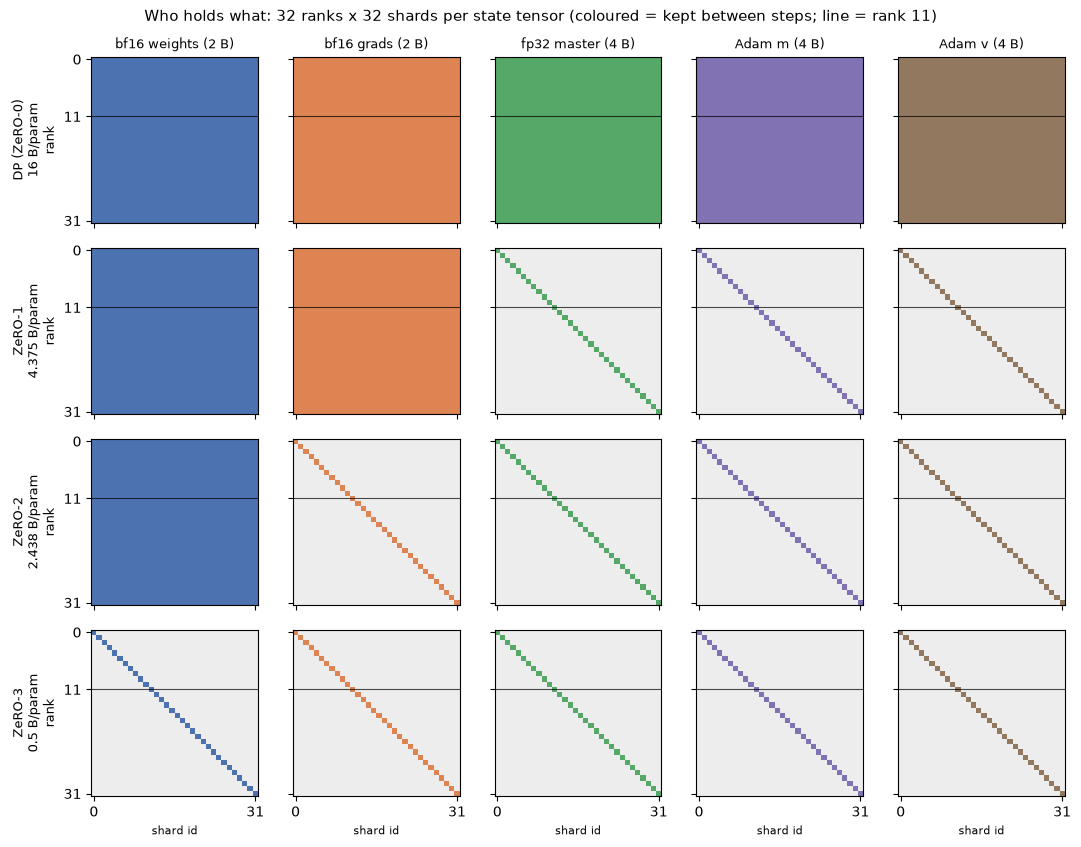

In [5]:
bpp32 = {st: measured_bytes_per_param(st, WORLD, layout) for st in range(4)}
fig = plots.ownership_grid(WORLD, RANK, bpp32, FIG / "ownership_grid.png"); plt.show()

Read the grid one row at a time. A full square means every rank holds every shard of that tensor, which is a replica. A diagonal means rank *k* holds only shard *k*. Counting coloured cells in rank 11's row and weighting by bytes gives that stage's bytes per parameter, which is what the next cell does with real tensor sizes.

## 3. Training-state accounting at N = 32

Expected from the notes' 16-byte model:

* DP: 2 + 2 + 4 + 4 + 4 = 16 B
* ZeRO-1: weights and grads replicated (4 B), the 12 optimizer bytes split 32 ways: 4 + 12/32 = 4.375 B
* ZeRO-2: only weights replicated (2 B): 2 + 14/32 = 2.4375 B
* ZeRO-3: everything split: 16/32 = 0.5 B

In [6]:
acc = []
for st in range(4):
    b = measured_rank_bytes(st, WORLD, layout, rank=RANK)
    acc.append(dict(stage=STAGE_NAMES[st], **{c: b[c] for c in CATEGORIES}, total_bytes=sum(b.values()),
                    measured_B_per_param=sum(b.values()) / P, formula_B_per_param=course_bytes_per_param(st, WORLD),
                    at_8_ranks=measured_bytes_per_param(st, 8, layout), course_table_8_GPUs=COURSE_BYTES_PER_PARAM_8GPU[st]))
acc = pd.DataFrame(acc)
for _, r in acc.iterrows():
    check(f"{r.stage}: bytes from rank state == course formula", abs(r.measured_B_per_param - r.formula_B_per_param) < 1e-12,
          (r.measured_B_per_param, r.formula_B_per_param))
    check(f"{r.stage}: 8-rank bytes/param == lesson table", abs(r.at_8_ranks - r.course_table_8_GPUs) < 0.005)
acc

,stage,param16,grad16,master32,adam_m,adam_v,total_bytes,measured_B_per_param,formula_B_per_param,at_8_ranks,course_table_8_GPUs
0,DP (ZeRO-0),1734144,1734144,3468288,3468288,3468288,13873152,16.0000,16.0000,16.00,16.00
1,ZeRO-1,1734144,1734144,108384,108384,108384,3793440,4.3750,4.3750,5.50,5.50
2,ZeRO-2,1734144,54192,108384,108384,108384,2113488,2.4375,2.4375,3.75,3.75
3,ZeRO-3,54192,54192,108384,108384,108384,433536,0.5000,0.5000,2.00,2.00


## 4. The three collectives, on real gradients

First a four-rank toy, small enough to read. Each rank holds four numbers; the values encode `rank*10 + position` so you can see where every number went.

In [7]:
toy = [torch.tensor([10. * r + i for i in range(4)]) for r in range(4)]
print("start            :", [t.tolist() for t in toy])
rs = ring_reduce_scatter(toy)
print("reduce-scatter   :", [t.tolist() for t in rs], " <- rank r holds only slice r of the sum")
ag = ring_all_gather(rs)
print("then all-gather  :", [t.tolist() for t in ag])
print("all-reduce       :", [t.tolist() for t in naive_all_reduce(toy)])

start            : [[0.0, 1.0, 2.0, 3.0], [10.0, 11.0, 12.0, 13.0], [20.0, 21.0, 22.0, 23.0], [30.0, 31.0, 32.0, 33.0]]
reduce-scatter   : [[60.0], [64.0], [68.0], [72.0]]  <- rank r holds only slice r of the sum
then all-gather  : [[60.0, 64.0, 68.0, 72.0], [60.0, 64.0, 68.0, 72.0], [60.0, 64.0, 68.0, 72.0], [60.0, 64.0, 68.0, 72.0]]
all-reduce       : [[60.0, 64.0, 68.0, 72.0], [60.0, 64.0, 68.0, 72.0], [60.0, 64.0, 68.0, 72.0], [60.0, 64.0, 68.0, 72.0]]


Now the real check. Each of the 32 ranks computes the fp32 gradient of its own micro-batch (2 sequences x 64 tokens) at the initial weights: 32 different vectors of 867,072 numbers. I combine them two ways:

* **naive all-reduce**: every rank receives every other rank's full vector and adds them up, an independent algorithm with nothing in common with the ring code
* **ring reduce-scatter, then ring all-gather**: the two-phase version that DP and ZeRO use in this simulator

In [8]:
corpus = Path("data/corpus.txt").read_bytes()
batches = make_batches(corpus, STEPS, WORLD, MICRO_BS, cfg.block_size, seed=1)
init = init_flat_params(cfg, layout, seed=0)
grads = local_gradients(cfg, init, *batches[0], WORLD)
check("32 distinct local gradients", len(grads) == 32 and not torch.equal(grads[0], grads[1]))

log_ring, log_naive = CommLog(WORLD), CommLog(WORLD)
t0 = time.perf_counter(); shards = ring_reduce_scatter(grads, log_ring, tag="rs"); full_ring = ring_all_gather(shards, log_ring, tag="ag"); t_ring = time.perf_counter() - t0
full_naive = naive_all_reduce(grads, log_naive, tag="naive")
f64 = torch.stack([g.double() for g in grads]).sum(0)          # float64 ground truth
err_rsag = max(float((a.double() - f64).abs().max()) for a in full_ring)
err_naive = max(float((a.double() - f64).abs().max()) for a in full_naive)
diff = max(float((a - b).abs().max()) for a, b in zip(full_ring, full_naive))
scale = float(f64.abs().max())
replicas_equal = all(torch.equal(full_ring[0], t) for t in full_ring)
bytes_ring = log_ring.bytes_sent(rank=RANK); bytes_naive = log_naive.bytes_sent(rank=RANK)
M = grads[0].numel() * 4
identity = dict(elements=grads[0].numel(), max_abs_value=scale,
                max_abs_diff_rsag_vs_naive=diff, max_abs_err_rsag_vs_fp64=err_rsag, max_abs_err_naive_vs_fp64=err_naive,
                all_32_results_identical=replicas_equal,
                rank11_bytes_sent_ring=bytes_ring, rank11_bytes_sent_naive=bytes_naive, buffer_bytes=M,
                ring_over_buffer=bytes_ring / M, naive_over_buffer=bytes_naive / M,
                rs_shard_elements=shards[RANK].numel())
check("RS + AG == all-reduce (fp32 rounding only)", diff <= 1e-6 * scale, diff)
check("every rank ends with the same reduced vector", replicas_equal)
check("ring sends 2(N-1)/N of the buffer per rank", bytes_ring == 2 * (WORLD - 1) * M // WORLD)
pd.Series(identity)

elements                         867072
max_abs_value                 23.770656
max_abs_diff_rsag_vs_naive     0.000004
max_abs_err_rsag_vs_fp64       0.000004
max_abs_err_naive_vs_fp64      0.000003
all_32_results_identical           True
rank11_bytes_sent_ring          6719808
rank11_bytes_sent_naive       107516928
buffer_bytes                    3468288
ring_over_buffer                 1.9375
naive_over_buffer                  31.0
rs_shard_elements                 27096
dtype: object

The difference between the two routes is fp32 rounding (the additions happen in a different order), and both are equally close to a float64 sum. The send counts also show why the ring matters: the naive version makes each rank send 31 full copies, the ring sends 1.94.

What makes this useful for ZeRO: after the reduce-scatter half, rank 11 already holds the fully averaged gradient for **its own** 1/32 slice. That is all it needs to update its 1/32 of the optimizer state. ZeRO-1 and ZeRO-2 stop there for gradients, and use the all-gather half to distribute updated **weights** instead of reduced gradients.

## 5. The DP baseline (ZeRO-0)

Every rank keeps all five tensors in full. One step: forward and backward on its own 2 sequences, ring all-reduce of the bf16 gradients (one per unit), gradient clipping at 1.0, Adam on the full model, cast the new fp32 master to bf16. Three steps, global batch 64 sequences x 64 tokens.

The run also measures, for rank 11: model FLOPs (PyTorch's `FlopCounterMode` around its forward and backward), bytes of activations saved for backward, and the temporary-buffer ledger.

A single-device reference that sees all 64 sequences at once, with plain autograd and no ranks, checks the DP baseline itself.

In [9]:
def keep(res):
    # drop the per-step activation lists etc. that we do not need; keep everything small
    return {k: v for k, v in res.items() if k != "ranks"}

ref = run_single_device(cfg, opt, init, batches)
rss0 = psutil.Process().memory_info().rss
runs = {}
t0 = time.perf_counter()
runs[0] = keep(run_stage(0, cfg, opt, init, batches, world=WORLD, probe_rank=RANK))
dp = runs[0]
peak_rss_dp = psutil.Process().memory_info().peak_wset if hasattr(psutil.Process().memory_info(), "peak_wset") else None
gc.collect()

mean_loss = [float(np.mean(s["losses"])) for s in dp["steps"]]
def rel_err(a_list, b_list):
    a, b = torch.cat([x.flatten().double() for x in a_list]), torch.cat([x.flatten().double() for x in b_list])
    return float((a - b).norm() / b.norm())
ref32 = torch.cat([g.flatten() for g in ref["first_grad_fp32"]])
avg32 = torch.stack(grads).mean(0)               # the 32 fp32 local gradients from section 4, averaged in fp32
dp_vs_ref = dict(loss_step1_dp=mean_loss[0], loss_step1_single_device=ref["losses"][0],
                 abs_loss_diff=abs(mean_loss[0] - ref["losses"][0]),
                 fp32_average_of_32_local_grads_rel_err=rel_err([avg32], [ref32]),
                 dp_bf16_ring_average_rel_err=rel_err(dp["first_grad"], [ref32]),
                 single_device_bf16_cast_rel_err=rel_err(ref["first_grad"], [ref32]),
                 one_bf16_rounding=2 ** -9)
check("DP replicas identical after 3 steps (all 5 tensors)", all(v == 0.0 for v in dp["replica_max_diff"].values()), dp["replica_max_diff"])
check("DP loss at step 1 == single-device loss", dp_vs_ref["abs_loss_diff"] < 1e-5, dp_vs_ref)
check("averaging 32 micro-batch gradients == one full-batch gradient (fp32)", dp_vs_ref["fp32_average_of_32_local_grads_rel_err"] < 1e-5, dp_vs_ref)
check("DP's bf16 ring average stays within a few bf16 roundings", dp_vs_ref["dp_bf16_ring_average_rel_err"] < 8 * 2 ** -9, dp_vs_ref)
print("mean loss per step (DP):          ", [round(x, 5) for x in mean_loss])
print("loss per step (one device, 64 seq):", [round(x, 5) for x in ref["losses"]])
print("max difference between any two replicas after 3 steps:", dp["replica_max_diff"])
print(f"rank {RANK} keeps {sum(dp['persistent_by_rank'][RANK].values()):,} bytes; all 32 ranks together {sum(sum(b.values()) for b in dp['persistent_by_rank']):,} bytes")
print(f"rank {RANK} ran Adam on {dp['optimizer_elements_by_rank'][RANK]:,} elements per step (= every parameter)")
print("simulator wall time (CPU, not a GPU prediction): %.1f s" % dp["wall_s"])
pd.Series(dp_vs_ref)

mean loss per step (DP):           [5.57006, 4.93795, 4.73438]
loss per step (one device, 64 seq): [5.57006, 4.93809, 4.7342]
max difference between any two replicas after 3 steps: {'param16': 0.0, 'master32': 0.0, 'adam_m': 0.0, 'adam_v': 0.0}
rank 11 keeps 13,873,152 bytes; all 32 ranks together 443,940,864 bytes
rank 11 ran Adam on 867,072 elements per step (= every parameter)
simulator wall time (CPU, not a GPU prediction): 13.6 s


loss_step1_dp                             5.570058e+00
loss_step1_single_device                  5.570057e+00
abs_loss_diff                             5.513430e-07
fp32_average_of_32_local_grads_rel_err    1.127567e-07
dp_bf16_ring_average_rel_err              5.618313e-03
single_device_bf16_cast_rel_err           1.732180e-03
one_bf16_rounding                         1.953125e-03
dtype: float64

The step-1 loss of the 32-rank run equals the single-device loss. For the gradient there are two separate questions. Is averaging 32 micro-batch gradients the same as one gradient over the whole batch? In fp32, yes, to rounding error. That is the notes' claim that data parallelism is the same training as one bigger batch. Then, how much does the bf16 wire format cost? The DP run casts each rank's gradient to bf16 and the ring re-rounds the partial sum at every one of its 31 hops, which leaves it a few bf16 roundings away from the fp32 answer (one rounding is 2^-9, about 0.002). That error is the same for every stage, because every stage averages through the same ring reduce-scatter. The 32 replicas end bitwise identical, because they started identical and applied the identical averaged gradient.

## 6. ZeRO-1: shard the optimizer state

What should change for rank 11: its fp32 master, `m` and `v` shrink to 1/32. Weights and gradient buffers stay full. After backward, a **reduce-scatter** puts the averaged gradient for rank 11's slice into rank 11's own region of its gradient buffer; the rest of that buffer still holds rank 11's local (unaveraged) gradient, which nobody reads. Rank 11 runs Adam on its slice only, and an **all-gather** of the new bf16 weight shards brings every replica back into agreement.

In [10]:
runs[1] = keep(run_stage(1, cfg, opt, init, batches, world=WORLD, probe_rank=RANK)); gc.collect()
r = runs[1]
by = r["persistent_by_rank"][RANK]; by_dp = dp["persistent_by_rank"][RANK]
print(f"{STAGE_NAMES[1]}: rank {RANK} keeps {sum(by.values()):,} bytes (DP: {sum(by_dp.values()):,}) -> {sum(by_dp.values()) / sum(by.values()):.2f}x less")
display(pd.DataFrame([dict(category=c, DP_bytes=by_dp[c], this_stage_bytes=by[c], ratio=f"{by_dp[c] / by[c]:.0f}x") for c in CATEGORIES]))
print("Adam elements per rank per step:", r["optimizer_elements_by_rank"][RANK], "| identical on all ranks:", len(set(r["optimizer_elements_by_rank"])) == 1)
print("collectives in one step (calls, bytes sent by one rank):", {f"{k[0]}/{k[1]}": (v["calls"], v["bytes_per_rank"]) for k, v in r["log"].summary(step=0).items()})
print("peak temporary bytes on rank", RANK, ":", r["peak_temp_by_rank"][RANK])
print("replica check (max diff between ranks for tensors that are still replicated):", r["replica_max_diff"])
d = max(float((a - b).abs().max()) for a, b in zip(r["final"]["master32"], dp["final"]["master32"]))
print(f"max |master weight - DP master weight| after {STEPS} steps: {d:.3e}")
check(f"{STAGE_NAMES[1]} persistent bytes == formula", sum(by.values()) == course_bytes_per_param(1, WORLD) * P)
check(f"{STAGE_NAMES[1]} optimizer work is 1/32", r["optimizer_elements_by_rank"] == [P // WORLD] * WORLD)

check("ZeRO-1 replicas of bf16 weights agree after all-gather", runs[1]["replica_max_diff"]["param16"] == 0.0)

ZeRO-1: rank 11 keeps 3,793,440 bytes (DP: 13,873,152) -> 3.66x less


,category,DP_bytes,this_stage_bytes,ratio
0,param16,1734144,1734144,1x
1,grad16,1734144,1734144,1x
2,master32,3468288,108384,32x
3,adam_m,3468288,108384,32x
4,adam_v,3468288,108384,32x


Adam elements per rank per step: 27096 | identical on all ranks: True
collectives in one step (calls, bytes sent by one rank): {'reduce_scatter/grad_reduce_scatter': (6, 1679952), 'all_reduce/grad_norm': (1, 4), 'all_gather/param_allgather_after_update': (6, 1679952)}
peak temporary bytes on rank 11 : 0
replica check (max diff between ranks for tensors that are still replicated): {'param16': 0.0}
max |master weight - DP master weight| after 3 steps: 1.863e-09


## 7. ZeRO-2: shard the gradients too

Under ZeRO-1, rank 11 still kept a full 1.7 MB gradient buffer of which it only ever read 1/32. ZeRO-2 drops it. As soon as a unit's backward is done, its bf16 gradient becomes a temporary **bucket**, the bucket is reduce-scattered, the owner keeps its averaged slice and the bucket is freed. So the full gradient of a unit exists only briefly, and never for the whole model at once.

The communication is the same as ZeRO-1: reduce-scatter of gradients and all-gather of updated weights.

In [11]:
runs[2] = keep(run_stage(2, cfg, opt, init, batches, world=WORLD, probe_rank=RANK)); gc.collect()
r = runs[2]
by = r["persistent_by_rank"][RANK]; by_dp = dp["persistent_by_rank"][RANK]
print(f"{STAGE_NAMES[2]}: rank {RANK} keeps {sum(by.values()):,} bytes (DP: {sum(by_dp.values()):,}) -> {sum(by_dp.values()) / sum(by.values()):.2f}x less")
display(pd.DataFrame([dict(category=c, DP_bytes=by_dp[c], this_stage_bytes=by[c], ratio=f"{by_dp[c] / by[c]:.0f}x") for c in CATEGORIES]))
print("Adam elements per rank per step:", r["optimizer_elements_by_rank"][RANK], "| identical on all ranks:", len(set(r["optimizer_elements_by_rank"])) == 1)
print("collectives in one step (calls, bytes sent by one rank):", {f"{k[0]}/{k[1]}": (v["calls"], v["bytes_per_rank"]) for k, v in r["log"].summary(step=0).items()})
print("peak temporary bytes on rank", RANK, ":", r["peak_temp_by_rank"][RANK])
print("replica check (max diff between ranks for tensors that are still replicated):", r["replica_max_diff"])
d = max(float((a - b).abs().max()) for a, b in zip(r["final"]["master32"], dp["final"]["master32"]))
print(f"max |master weight - DP master weight| after {STEPS} steps: {d:.3e}")
check(f"{STAGE_NAMES[2]} persistent bytes == formula", sum(by.values()) == course_bytes_per_param(2, WORLD) * P)
check(f"{STAGE_NAMES[2]} optimizer work is 1/32", r["optimizer_elements_by_rank"] == [P // WORLD] * WORLD)

check("ZeRO-2 replicas of bf16 weights agree after all-gather", runs[2]["replica_max_diff"]["param16"] == 0.0)
largest = max(u.numel for u in layout)
check("ZeRO-2 temporary peak is one unit's bf16 gradient bucket", runs[2]["peak_temp_by_rank"][RANK] == 2 * largest)

ZeRO-2: rank 11 keeps 2,113,488 bytes (DP: 13,873,152) -> 6.56x less


,category,DP_bytes,this_stage_bytes,ratio
0,param16,1734144,1734144,1x
1,grad16,1734144,54192,32x
2,master32,3468288,108384,32x
3,adam_m,3468288,108384,32x
4,adam_v,3468288,108384,32x


Adam elements per rank per step: 27096 | identical on all ranks: True
collectives in one step (calls, bytes sent by one rank): {'reduce_scatter/grad_reduce_scatter': (6, 1679952), 'all_reduce/grad_norm': (1, 4), 'all_gather/param_allgather_after_update': (6, 1679952)}
peak temporary bytes on rank 11 : 396544
replica check (max diff between ranks for tensors that are still replicated): {'param16': 0.0}
max |master weight - DP master weight| after 3 steps: 1.863e-09


## 8. ZeRO-3: shard the weights, gather them only when needed

Now rank 11 stores 1/32 of the bf16 weights too. To run a unit it needs the whole unit, so:

```
forward,  for each unit:   all-gather weights -> compute -> free the gathered weights
backward, for each unit:   all-gather weights again -> compute grads -> reduce-scatter grads -> free both
```

The release is real. The gathered fp32 compute copy has its storage resized to zero after the unit's forward (the engine asserts this), and autograd's saved references to the weights are replaced by placeholders through `torch.autograd.graph.saved_tensors_hooks`. During backward the placeholders are filled from the second all-gather. Freeing storage this way is how FSDP releases gathered weights, and it means ZeRO-3 here does **not** recompute anything: the FLOP count stays equal to DP's.

After the update no all-gather is needed: each owner just writes its own new shard.

In [12]:
runs[3] = keep(run_stage(3, cfg, opt, init, batches, world=WORLD, probe_rank=RANK)); gc.collect()
r = runs[3]
by = r["persistent_by_rank"][RANK]; by_dp = dp["persistent_by_rank"][RANK]
print(f"{STAGE_NAMES[3]}: rank {RANK} keeps {sum(by.values()):,} bytes (DP: {sum(by_dp.values()):,}) -> {sum(by_dp.values()) / sum(by.values()):.2f}x less")
display(pd.DataFrame([dict(category=c, DP_bytes=by_dp[c], this_stage_bytes=by[c], ratio=f"{by_dp[c] / by[c]:.0f}x") for c in CATEGORIES]))
print("Adam elements per rank per step:", r["optimizer_elements_by_rank"][RANK], "| identical on all ranks:", len(set(r["optimizer_elements_by_rank"])) == 1)
print("collectives in one step (calls, bytes sent by one rank):", {f"{k[0]}/{k[1]}": (v["calls"], v["bytes_per_rank"]) for k, v in r["log"].summary(step=0).items()})
print("peak temporary bytes on rank", RANK, ":", r["peak_temp_by_rank"][RANK])
print("replica check (max diff between ranks for tensors that are still replicated):", r["replica_max_diff"])
d = max(float((a - b).abs().max()) for a, b in zip(r["final"]["master32"], dp["final"]["master32"]))
print(f"max |master weight - DP master weight| after {STEPS} steps: {d:.3e}")
check(f"{STAGE_NAMES[3]} persistent bytes == formula", sum(by.values()) == course_bytes_per_param(3, WORLD) * P)
check(f"{STAGE_NAMES[3]} optimizer work is 1/32", r["optimizer_elements_by_rank"] == [P // WORLD] * WORLD)

z3 = runs[3]
gathers = [c for c in z3["log"].calls if c["step"] == 0 and c["op"] == "all_gather"]
held = z3["steps"][0]["held_params_between_fwd_bwd"][RANK]
check("ZeRO-3 gathers every unit twice per step", len(gathers) == 2 * len(layout), len(gathers))
check("ZeRO-3: between forward and backward rank holds only its 1/32 weight shard", held == 2 * P // WORLD, held)
check("ZeRO-3 temporary peak = gathered unit + its gradient bucket", z3["peak_temp_by_rank"][RANK] == 4 * largest)
print(f"weights held by rank {RANK} between forward and backward: {held:,} bytes "
      f"(DP/ZeRO-1/ZeRO-2: {2 * P:,} bytes)")
print(f"gather events in one step: {len(gathers)} (forward {sum(c['tag'].endswith('fwd') for c in gathers)}, backward {sum(c['tag'].endswith('bwd') for c in gathers)})")
print(f"peak temporary bytes: {z3['peak_temp_by_rank'][RANK]:,} = gathered block ({2 * largest:,}) + its gradient bucket ({2 * largest:,})")

ZeRO-3: rank 11 keeps 433,536 bytes (DP: 13,873,152) -> 32.00x less


,category,DP_bytes,this_stage_bytes,ratio
0,param16,1734144,54192,32x
1,grad16,1734144,54192,32x
2,master32,3468288,108384,32x
3,adam_m,3468288,108384,32x
4,adam_v,3468288,108384,32x


Adam elements per rank per step: 27096 | identical on all ranks: True
collectives in one step (calls, bytes sent by one rank): {'all_gather/param_gather_fwd': (6, 1679952), 'all_gather/param_gather_bwd': (6, 1679952), 'reduce_scatter/grad_reduce_scatter': (6, 1679952), 'all_reduce/grad_norm': (1, 4)}
peak temporary bytes on rank 11 : 793088
replica check (max diff between ranks for tensors that are still replicated): {}
max |master weight - DP master weight| after 3 steps: 1.863e-09
weights held by rank 11 between forward and backward: 54,192 bytes (DP/ZeRO-1/ZeRO-2: 1,734,144 bytes)
gather events in one step: 12 (forward 6, backward 6)
peak temporary bytes: 793,088 = gathered block (396,544) + its gradient bucket (396,544)


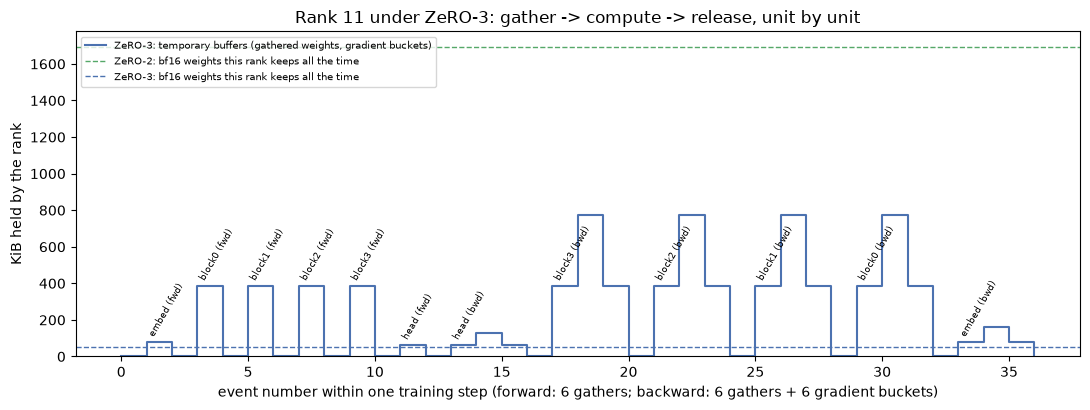

first 8 ZeRO-3 events on rank 11 : [('+gather embed (fwd)', 81920), ('-release embed (fwd)', 0), ('+gather block0 (fwd)', 396544), ('-release block0 (fwd)', 0), ('+gather block1 (fwd)', 396544), ('-release block1 (fwd)', 0), ('+gather block2 (fwd)', 396544), ('-release block2 (fwd)', 0)]
ZeRO-2 for comparison: its only temporary buffer is one gradient bucket, peak 396544 bytes


In [13]:
trace3 = runs[3]["temp_trace_probe"][:len(runs[3]["temp_trace_probe"]) // STEPS]          # step 1 only
check("ZeRO-3 trace returns to zero temporary bytes after every unit", all(b == 0 for ev, b in trace3 if ev.startswith("-release")))
fig = plots.temp_timeline(trace3, RANK, {2: runs[2]["persistent_by_rank"][RANK]["param16"], 3: runs[3]["persistent_by_rank"][RANK]["param16"]},
                          FIG / "zero3_gather_release_timeline.png"); plt.show()
print("first 8 ZeRO-3 events on rank", RANK, ":", trace3[:8])
print("ZeRO-2 for comparison: its only temporary buffer is one gradient bucket, peak", runs[2]["peak_temp_by_rank"][RANK], "bytes")

The sawtooth is rank 11 under ZeRO-3. A block's weights appear (gather, 387 KiB), get used, and drop back to zero before the next block arrives. In backward each block is gathered again and its gradient bucket appears next to it, which gives the taller teeth (775 KiB). The dashed lines are the bf16 weights a rank keeps all the time: the full 1.65 MiB copy under ZeRO-2, 53 KiB under ZeRO-3. So even ZeRO-3's worst moment in the step is below what ZeRO-2 holds permanently, and the price is the 12 gathers.

## 9. Did the update stay the same?

DP is the reference. For each ZeRO stage I compare the fp32 master weights, stitched back together from the 32 shards (an inspection step outside the simulation, not a collective). I also rerun all four stages with clipping switched off, as a control for the one place where the stages legitimately do arithmetic in a different order: the global gradient norm. DP computes it on one full gradient; ZeRO ranks each square-sum their own shard and all-reduce 32 partial sums.

Tolerance: 1e-5, which is 1% of the size of one Adam step (lr = 1e-3).

In [14]:
TOL = 1e-5
def max_mean_diff(a_list, b_list):
    d = torch.cat([(a - b).abs().flatten() for a, b in zip(a_list, b_list)])
    return float(d.max()), float(d.mean()), int((d > 0).sum())

noclip = {}
opt_nc = OptConfig(clip=1e9)
for st in range(4):
    res = run_stage(st, cfg, opt_nc, init, batches, world=WORLD, probe_rank=None)
    noclip[st] = res["final"]["master32"]; del res; gc.collect()

eq = []
for st in range(4):
    r = runs[st]
    grad_equal = all(torch.equal(a, b) for a, b in zip(r["first_grad"], dp["first_grad"]))
    d1, _, _ = max_mean_diff(r["master_after_step1"], dp["master_after_step1"])
    d3, m3, n3 = max_mean_diff(r["final"]["master32"], dp["final"]["master32"])
    dn, _, nn = max_mean_diff(noclip[st], noclip[0])
    loss_equal = all(np.mean(a["losses"]) == np.mean(b["losses"]) for a, b in zip(r["steps"], dp["steps"]))
    bf16_equal = all(torch.equal(a, b) for a, b in zip(r["final"]["param16_rank0"], dp["final"]["param16_rank0"]))
    eq.append(dict(stage=STAGE_NAMES[st], step1_avg_grad_bitwise_equal=grad_equal, step1_max_abs_diff=d1,
                   step3_max_abs_diff=d3, step3_mean_abs_diff=m3, step3_elements_differing=n3,
                   step3_max_abs_diff_no_clip=dn, step3_elements_differing_no_clip=nn,
                   clip_coef_step1=r["steps"][0]["clip_coef"], same_loss_all_steps=loss_equal,
                   final_bf16_weights_bitwise_equal=bf16_equal,
                   result="PASS" if (d3 <= TOL and dn <= TOL and grad_equal) else "FAIL"))
eq = pd.DataFrame(eq)
for _, row in eq.iterrows():
    check(f"{row.stage}: update matches DP within {TOL}", row.result == "PASS", row.to_dict())
pd.set_option("display.float_format", lambda x: f"{x:.3e}" if abs(x) < 1e-2 and x != 0 else f"{x:.6g}")
eq

,stage,step1_avg_grad_bitwise_equal,step1_max_abs_diff,step3_max_abs_diff,step3_mean_abs_diff,step3_elements_differing,step3_max_abs_diff_no_clip,step3_elements_differing_no_clip,clip_coef_step1,same_loss_all_steps,final_bf16_weights_bitwise_equal,result
0,DP (ZeRO-0),True,0,0,0,0,0,0,0.124044,True,True,PASS
1,ZeRO-1,True,0,1.863e-09,1.816e-14,39,1.863e-09,44,0.124044,True,True,PASS
2,ZeRO-2,True,0,1.863e-09,1.816e-14,39,1.863e-09,44,0.124044,True,True,PASS
3,ZeRO-3,True,0,1.863e-09,1.816e-14,39,1.863e-09,44,0.124044,True,True,PASS


I expected exact zeros. The table is close to that but not quite, and the reason is worth knowing:

* The averaged gradient at step 1 is **bitwise identical** in all four stages. They all average through the same ring reduce-scatter, and all-gather only copies bytes.
* After step 1 the master weights are also bitwise identical, even though the clip coefficients are not. DP computes the gradient norm from one full gradient; ZeRO ranks each square-sum their own shard and all-reduce 32 partial sums, so the two coefficients differ in about the 8th digit. But the coefficient multiplies an fp32 gradient, and the next cell shows both coefficients round to the same fp32 number at every step, so the clipped gradients are bitwise identical and the norm difference never reaches a tensor.
* After step 3, a few dozen of the 867,072 master weights differ from DP by 1.86e-9. That is one fp32 ulp for weights of this size (between 2^-6 and 2^-5). Turning clipping off gives the same picture, consistent with the norm not being the cause.
* Losses are identical at every step in every stage. A one-ulp difference in an fp32 master weight did not change any bf16 weight, so every forward pass saw the same numbers.

The next cell finds the source without any ranks or communication at all: run the same Adam update, with the same inputs, once on whole unit vectors and once on 32 slices of each.

In [15]:
clip = pd.DataFrame([dict(step=i + 1, DP=runs[0]["steps"][i]["clip_coef"], ZeRO=runs[1]["steps"][i]["clip_coef"],
                          same_in_float64=runs[0]["steps"][i]["clip_coef"] == runs[1]["steps"][i]["clip_coef"],
                          same_after_rounding_to_fp32=bool(np.float32(runs[0]["steps"][i]["clip_coef"]) == np.float32(runs[1]["steps"][i]["clip_coef"])),
                          scaled_grad_bitwise_equal=torch.equal(dp["first_grad"][1] * runs[0]["steps"][i]["clip_coef"], dp["first_grad"][1] * runs[1]["steps"][i]["clip_coef"]))
                     for i in range(STEPS)])
check("ZeRO stages share one clip coefficient", all(runs[st]["steps"][i]["clip_coef"] == runs[1]["steps"][i]["clip_coef"] for st in (2, 3) for i in range(STEPS)))
with pd.option_context("display.float_format", repr):
    display(clip)
from zero_sim.engine import adam_update
avg = [torch.stack(local_gradients(cfg, init, *batches[k], WORLD)).mean(0).to(torch.bfloat16) for k in range(STEPS)]
full = [torch.cat(init).clone(), torch.zeros(P), torch.zeros(P)]
starts = np.cumsum([0] + [u.numel for u in layout])
pieces = [(int(starts[i]) + r * (u.numel // WORLD), u.numel // WORLD) for i, u in enumerate(layout) for r in range(WORLD)]
shard_state = {lo: [full[0][lo:lo + n].clone(), torch.zeros(n), torch.zeros(n)] for lo, n in pieces}
kernel = []
for t in range(1, STEPS + 1):
    adam_update(*full, avg[t - 1], t, 0.5, opt)
    for lo, n in pieces:
        adam_update(*shard_state[lo], avg[t - 1][lo:lo + n], t, 0.5, opt)
    stitched = torch.cat([shard_state[lo][0] for lo, n in pieces])
    dd = (stitched - full[0]).abs()
    # where inside each slice do the differences sit?
    in_tail = 0
    for lo, n in pieces:
        idx = torch.nonzero((shard_state[lo][0] - full[0][lo:lo + n]) != 0).flatten()
        in_tail += int((idx >= n - n % 16).sum())
    kernel.append(dict(adam_step=t, max_abs_diff=float(dd.max()), elements_differing=int((dd > 0).sum()),
                       of_which_in_last_len_mod_16_of_a_slice=in_tail))
kernel = pd.DataFrame(kernel)
check("all kernel differences sit in the vector-loop tail of a slice", (kernel.elements_differing == kernel.of_which_in_last_len_mod_16_of_a_slice).all())
print("slice lengths and length mod 16:", {u.name: (u.numel // WORLD, (u.numel // WORLD) % 16) for u in layout})
check("Adam on 32 slices == Adam on the whole vector at step 1", kernel.max_abs_diff.iloc[0] == 0.0)
check("later differences are a few fp32 ulps", kernel.max_abs_diff.max() <= 4 * 2 ** -29)
kernel

,step,DP,ZeRO,same_in_float64,same_after_rounding_to_fp32,scaled_grad_bitwise_equal
0,1,np.float64(0.12404414538705444),np.float64(0.12404413969880089),False,True,True
1,2,np.float64(0.2492801877283814),np.float64(0.24928018784379405),False,True,True
2,3,np.float64(0.33545621691635336),np.float64(0.3354562371666007),False,True,True


slice lengths and length mod 16: {'embed': (1280, 0), 'block0': (6196, 4), 'block1': (6196, 4), 'block2': (6196, 4), 'block3': (6196, 4), 'head': (1032, 8)}


,adam_step,max_abs_diff,elements_differing,of_which_in_last_len_mod_16_of_a_slice
0,1,0,0,0
1,2,1.863e-09,35,35
2,3,3.725e-09,65,65


Same pattern with no ZeRO at all: exact after the first update, then a few dozen elements one or two ulps apart. Every differing element sits in the last (length mod 16) positions of a slice, the leftover after the vectorised loop that handles 16 floats at a time here; a block slice is 6,196 long (remainder 4), and the embedding slices (1,280, remainder 0) never differ. So the vectorised loop and its scalar tail round slightly differently, a whole tensor and a slice put different elements in the tail, and by Adam's second step that shows up in the last bit. So the stages do not change the update. They change where the state lives and what gets sent, and the only residue is floating-point evaluation order.

## 10. Memory, measured from real tensors

process peak working set so far, read right after the DP run: 882 MiB (the 32 real replicas are 423 MiB)


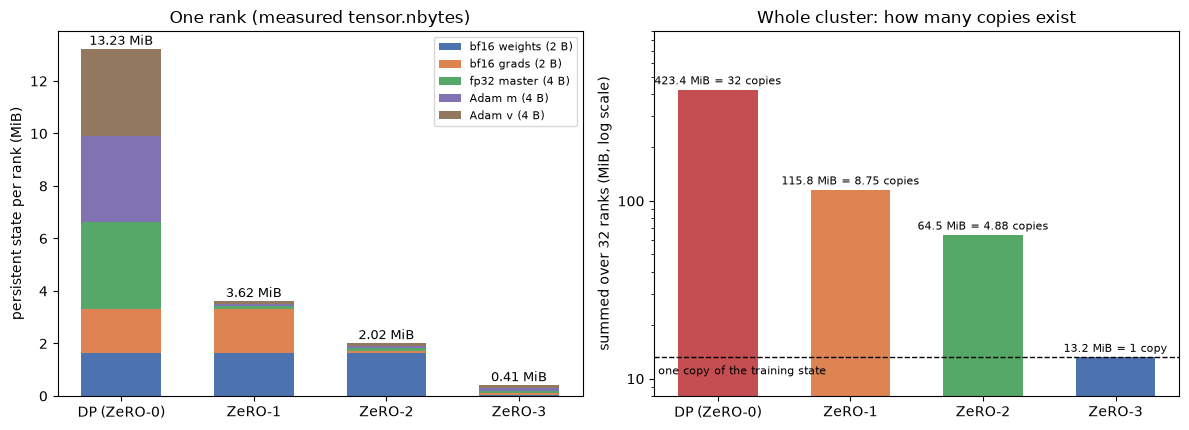

,stage,bytes_per_rank,MiB_per_rank,B_per_param,all_ranks_equal,cluster_total_MiB,copies_of_state,saved_vs_DP,peak_temp_bytes
0,DP (ZeRO-0),13873152,13.2305,16,True,423.375,32,0.0%,0
1,ZeRO-1,3793440,3.61771,4.375,True,115.767,8.75,72.7%,0
2,ZeRO-2,2113488,2.01558,2.4375,True,64.4985,4.875,84.8%,396544
3,ZeRO-3,433536,0.413452,0.5,True,13.2305,1,96.9%,793088


In [16]:
mem = []
for st in range(4):
    r = runs[st]
    per_rank = [sum(b.values()) for b in r["persistent_by_rank"]]
    meta_b = sum(measured_rank_bytes(st, WORLD, layout, rank=RANK).values())
    check(f"{STAGE_NAMES[st]}: real tensors == meta construction == formula, on all 32 ranks",
          set(per_rank) == {meta_b} and meta_b == course_bytes_per_param(st, WORLD) * P)
    mem.append(dict(stage=STAGE_NAMES[st], bytes_per_rank=per_rank[RANK], MiB_per_rank=per_rank[RANK] / 2**20,
                    B_per_param=per_rank[RANK] / P, all_ranks_equal=len(set(per_rank)) == 1,
                    cluster_total_MiB=sum(per_rank) / 2**20, copies_of_state=sum(per_rank) / (16 * P),
                    saved_vs_DP=f"{1 - per_rank[RANK] / (16 * P):.1%}",
                    peak_temp_bytes=r["peak_temp_by_rank"][RANK]))
mem = pd.DataFrame(mem)
check("stage ordering DP > Z1 > Z2 > Z3", list(mem.bytes_per_rank) == sorted(mem.bytes_per_rank, reverse=True))
if peak_rss_dp: print(f"process peak working set so far, read right after the DP run: {peak_rss_dp / 2**20:.0f} MiB (the 32 real replicas are {32 * 16 * P / 2**20:.0f} MiB)")
fig = plots.memory_per_rank({st: runs[st]["persistent_by_rank"][RANK] for st in range(4)}, WORLD, 16 * P, FIG / "memory_per_rank.png"); plt.show()
mem

## 11. Computation and communication

Three kinds of work, kept separate:

* **model compute**: forward and backward matmuls for rank 11's micro-batch, counted by `FlopCounterMode`
* **optimizer work**: how many parameters rank 11 runs Adam on
* **communication**: bytes rank 11 sends per step, summed from the ring send log, in units of P (P = 2 bytes x 867,072 = one bf16 copy of the weights)

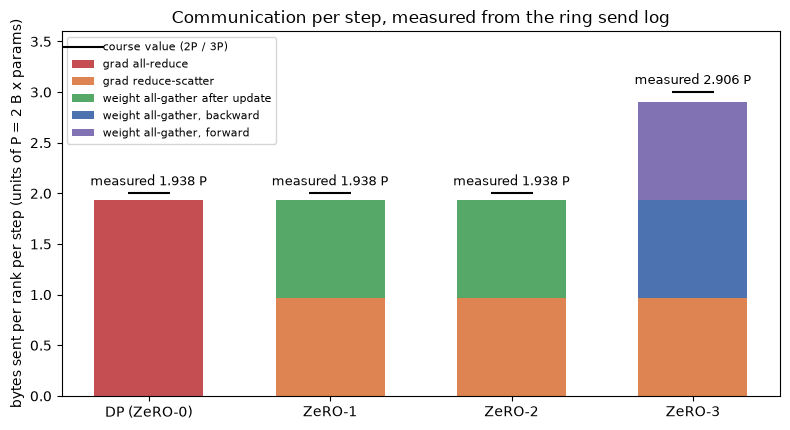

,stage,fwd_GFLOP,bwd_GFLOP,adam_elements_rank,adam_elements_cluster,grad_norm_work,sent_per_rank_P,ring_formula_P,course_P,scalar_norm_bytes,collective_calls,p2p_sends_all_ranks
0,DP (ZeRO-0),0.2265,0.453,867072,27746304,full grad on every rank,1.938,1.938,2,0,6,11904
1,ZeRO-1,0.2265,0.453,27096,867072,own shard + scalar all-reduce,1.938,1.938,2,4,13,11936
2,ZeRO-2,0.2265,0.453,27096,867072,own shard + scalar all-reduce,1.938,1.938,2,4,13,11936
3,ZeRO-3,0.2265,0.453,27096,867072,own shard + scalar all-reduce,2.906,2.906,3,4,19,17888


In [17]:
P_BYTES = 2 * P
LABEL = {"grad_allreduce": "grad all-reduce", "grad_reduce_scatter": "grad reduce-scatter",
         "param_allgather_after_update": "weight all-gather after update",
         "param_gather_fwd": "weight all-gather, forward", "param_gather_bwd": "weight all-gather, backward"}
comp, comm_rows = [], {}
for st in range(4):
    r = runs[st]; s0 = r["log"].summary(step=0)
    by_tag = {LABEL[k[1]]: v["bytes_per_rank"] / P_BYTES for k, v in s0.items() if k[1] in LABEL}
    comm_rows[st] = by_tag
    sent = sum(v["bytes_per_rank"] for k, v in s0.items() if k[1] in LABEL)
    norm_bytes = sum(v["bytes_per_rank"] for k, v in s0.items() if k[1] == "grad_norm")
    calls = sum(v["calls"] for k, v in s0.items()); sends = sum(v["p2p_sends"] for k, v in s0.items())
    comp.append(dict(stage=STAGE_NAMES[st],
                     fwd_GFLOP=r["steps"][0]["probe"]["flops_fwd"] / 1e9, bwd_GFLOP=r["steps"][0]["probe"]["flops_bwd"] / 1e9,
                     adam_elements_rank=r["optimizer_elements_by_rank"][RANK],
                     adam_elements_cluster=sum(r["optimizer_elements_by_rank"]),
                     grad_norm_work="full grad on every rank" if st == 0 else "own shard + scalar all-reduce",
                     sent_per_rank_P=sent / P_BYTES, ring_formula_P=ring_comm_P(st, WORLD), course_P=COURSE_COMM_P[st],
                     scalar_norm_bytes=norm_bytes, collective_calls=calls, p2p_sends_all_ranks=sends))
comp = pd.DataFrame(comp)
for _, row in comp.iterrows():
    check(f"{row.stage}: measured comm == ring formula", abs(row.sent_per_rank_P - row.ring_formula_P) < 1e-12)
    check(f"{row.stage}: comm within 1/N of course value", abs(row.sent_per_rank_P - row.course_P) <= row.course_P / WORLD + 1e-12)
check("model FLOPs identical in all stages", comp.fwd_GFLOP.nunique() == 1 and comp.bwd_GFLOP.nunique() == 1)
# analytic check of the FLOP counter: 2 * (matmul params) * tokens, plus attention scores and mixing
tok = MICRO_BS * cfg.block_size; d = cfg.d_model
matmul_params = cfg.n_layer * 12 * d * d + cfg.vocab_size * d
attn = cfg.n_layer * 2 * 2 * MICRO_BS * cfg.block_size ** 2 * d
check("FLOP counter matches analytic forward count", comp.fwd_GFLOP.iloc[0] * 1e9 == 2 * matmul_params * tok + attn)
fig = plots.communication(comm_rows, COURSE_COMM_P, FIG / "communication.png"); plt.show()
pd.set_option("display.float_format", lambda x: f"{x:.4g}")
comp

The measured volumes are 1.9375 P and 2.906 P rather than exactly 2P and 3P because each ring phase sends (N-1)/N of the buffer; the course rounds that to 1. The interesting part is not the total but what travels:

* DP's all-gather half carries **averaged gradients**.
* ZeRO-1/2 skip that, and their all-gather carries **updated weights**. Same size, different payload, so the memory saving costs no extra traffic.
* ZeRO-3 has no all-gather after the update but two during the step (forward and backward), one more P than the others.

Model FLOPs are identical across stages, to the FLOP. Optimizer work is where the redundancy was: under DP the cluster runs Adam on 27.7 M elements to update 0.87 M parameters, under any ZeRO stage it runs on exactly 0.87 M.

## 12. More ranks: where each stage hits a floor

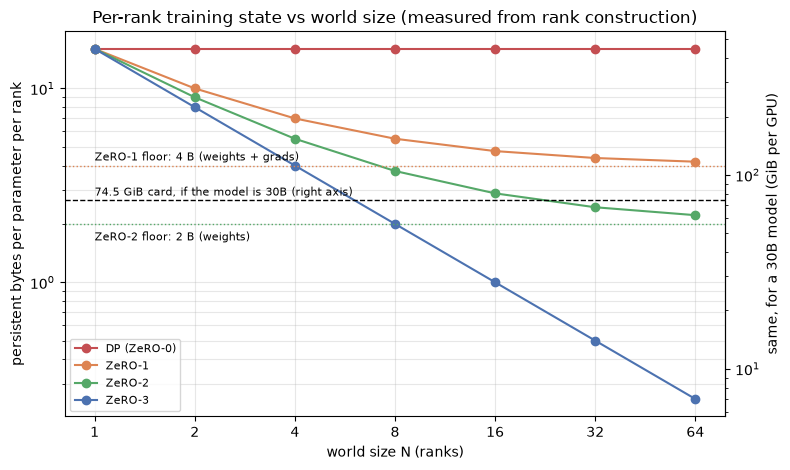

,DP (ZeRO-0),ZeRO-1,ZeRO-2,ZeRO-3
N,,,,
1,16,16,16,16
2,16,10,9,8
4,16,7,5.5,4
8,16,5.5,3.75,2
16,16,4.75,2.875,1
32,16,4.375,2.438,0.5
64,16,4.188,2.219,0.25


In [18]:
worlds = [1, 2, 4, 8, 16, 32, 64]
bpp = {st: {n: measured_bytes_per_param(st, n, layout) for n in worlds} for st in range(4)}
for st in range(4):
    for n in worlds:
        check(f"{STAGE_NAMES[st]} N={n}: measured == formula", abs(bpp[st][n] - course_bytes_per_param(st, n)) < 1e-12)
gib_per_bpp = 30e9 / GIB
fig = plots.world_size_scaling(worlds, bpp, CARD_GIB / gib_per_bpp, gib_per_bpp, FIG / "world_size_scaling.png"); plt.show()
scal = pd.DataFrame({STAGE_NAMES[st]: bpp[st] for st in range(4)}); scal.index.name = "N"
scal

DP is flat: more ranks bring more copies, not less memory per rank. ZeRO-1 can only squeeze the 12 optimizer bytes, so it bends toward 4 B (weights + grads). ZeRO-2 bends toward 2 B (weights). Only ZeRO-3 keeps falling as 16/N.

## 13. The same accounting at 30B

Same code: the share of each state category that one rank holds is read off our model's rank construction, then multiplied by 30 x 10^9 parameters. The notes' ladder is only used as the thing to compare against.

In [19]:
lad = []
for st in range(4):
    row = dict(stage=STAGE_NAMES[st])
    for n in (8, 16, 32, 64):
        g = project_gib_per_gpu(st, n, layout)
        row[f"N={n} GiB"] = round(g, 2); row[f"N={n} course"] = COURSE_LADDER_30B_GIB[st][n]
        check(f"30B {STAGE_NAMES[st]} N={n} matches lesson", abs(g - COURSE_LADDER_30B_GIB[st][n]) <= 0.051, (g, COURSE_LADDER_30B_GIB[st][n]))
    row["fits 74.5 GiB at N=32"] = project_gib_per_gpu(st, 32, layout) <= CARD_GIB
    row["smallest N that fits (<=1024)"] = next((n for n in [2 ** k for k in range(11)] if project_gib_per_gpu(st, n, layout) <= CARD_GIB), "never")
    lad.append(row)
lad = pd.DataFrame(lad)
floor_params = CARD_GIB * GIB / 4
check("4 B/param floor fills a 74.5 GiB card at 20B parameters", abs(floor_params / 1e9 - 20.0) < 0.01, floor_params)
check("at N=32 only ZeRO-2 and ZeRO-3 fit", list(lad["fits 74.5 GiB at N=32"]) == [False, False, True, True])
print(f"card = 80 GB = {CARD_GIB:.2f} GiB | 30B x 16 B = {30e9 * 16 / GIB:.1f} GiB | replicated weights+grads floor = {30e9 * 4 / GIB:.1f} GiB "
      f"| the 4 B floor alone fills the card at {floor_params / 1e9:.2f} B params")
lad

card = 80 GB = 74.51 GiB | 30B x 16 B = 447.0 GiB | replicated weights+grads floor = 111.8 GiB | the 4 B floor alone fills the card at 20.00 B params


,stage,N=8 GiB,N=8 course,N=16 GiB,N=16 course,N=32 GiB,N=32 course,N=64 GiB,N=64 course,fits 74.5 GiB at N=32,smallest N that fits (<=1024)
0,DP (ZeRO-0),447,447,447,447,447,447,447,447,False,never
1,ZeRO-1,153.7,153.7,132.7,132.7,122.2,122.2,117,117,False,never
2,ZeRO-2,104.8,104.8,80.33,80.3,68.1,68.1,61.99,62,True,32
3,ZeRO-3,55.88,55.9,27.94,27.9,13.97,14,6.98,7,True,8


## 14. Activations are not in that table

Every number above is model state: weights, gradients, optimizer. The activations a rank saves during forward for use in backward are extra, and they depend on batch size and sequence length, not on the ZeRO stage. Below are the bytes rank 11 had saved for backward (counted by the same saved-tensor hook that ZeRO-3 uses, unique storages only). In this simulator activations are fp32; on a GPU with bf16 they would be about half.

In [20]:
act = pd.DataFrame([dict(stage=STAGE_NAMES[st],
                         activation_bytes_saved=runs[st]["steps"][0]["activation_bytes"][RANK],
                         persistent_model_state_bytes=sum(runs[st]["persistent_by_rank"][RANK].values()))
                    for st in range(4)])
act["activations / model state"] = act.activation_bytes_saved / act.persistent_model_state_bytes
check("activations identical in every stage", act.activation_bytes_saved.nunique() == 1)
act

,stage,activation_bytes_saved,persistent_model_state_bytes,activations / model state
0,DP (ZeRO-0),5071876,13873152,0.3656
1,ZeRO-1,5071876,3793440,1.337
2,ZeRO-2,5071876,2113488,2.4
3,ZeRO-3,5071876,433536,11.7


For this toy, with 2 sequences of 64 tokens per rank, activations are about a third of DP's state. In fp32 (as simulated) they are already bigger than everything ZeRO-1, ZeRO-2 or ZeRO-3 keeps permanently; at roughly half that size in bf16 they would still exceed ZeRO-2's and ZeRO-3's state. That is the notes' warning in miniature: a stage that "fits" on the state table can still run out of memory once activations are added, and the stage choice does nothing about them (recomputation does).

## 15. Break it: what each collective is for

Three one-line faults, one step each, on the full 32-rank setup:

* DP without the gradient all-reduce
* ZeRO-1 without the all-gather of updated weights
* ZeRO-3 gathering shards from the wrong owner (rank r's shard is placed where rank r-1's belongs)

In [21]:
one = batches[:1]
br = []
b0 = run_stage(0, cfg, opt, init, one, world=WORLD, probe_rank=None, faults={"skip_grad_sync"})
br.append(dict(fault="DP: skip gradient all-reduce", effect="max weight difference between replicas", value=b0["replica_max_diff"]["param16"])); del b0; gc.collect()
b1 = run_stage(1, cfg, opt, init, one, world=WORLD, probe_rank=None, faults={"skip_param_allgather"})
br.append(dict(fault="ZeRO-1: skip weight all-gather", effect="max weight difference between replicas", value=b1["replica_max_diff"]["param16"])); del b1
good = run_stage(3, cfg, opt, init, one, world=WORLD, probe_rank=None)
bad = run_stage(3, cfg, opt, init, one, world=WORLD, probe_rank=None, faults={"wrong_gather"})
br.append(dict(fault="ZeRO-3: gather from wrong owner", effect="step-1 mean loss (correct run: %.5f)" % np.mean(good["steps"][0]["losses"]),
               value=float(np.mean(bad["steps"][0]["losses"]))))
del good, bad; gc.collect()
br = pd.DataFrame(br)
check("removing a collective breaks agreement", br.value.iloc[0] > 0 and br.value.iloc[1] > 0 and abs(br.value.iloc[2] - np.mean(runs[3]["steps"][0]["losses"])) > 1e-3)
br

,fault,effect,value
0,DP: skip gradient all-reduce,max weight difference between replicas,0.002441
1,ZeRO-1: skip weight all-gather,max weight difference between replicas,0.001465
2,ZeRO-3: gather from wrong owner,step-1 mean loss (correct run: 5.57006),5.544


Without the all-reduce, each DP replica steps with its own 2-sequence gradient and the 32 "copies" stop being copies after one step. Without the all-gather, each ZeRO-1 rank has only updated its own 1/32 of the weights and holds stale values for the other 31/32. With the wrong shards, ZeRO-3 runs forward through a scrambled model and the loss is visibly different. Each collective is the thing that keeps a sharded system equivalent to the unsharded one.

## 16. Save the evidence

In [22]:
def jsonable(x):
    if isinstance(x, dict): return {str(k): jsonable(v) for k, v in x.items()}
    if isinstance(x, (list, tuple)): return [jsonable(v) for v in x]
    if isinstance(x, (np.integer,)): return int(x)
    if isinstance(x, (np.floating,)): return float(x)
    if isinstance(x, (np.bool_,)): return bool(x)
    return x

units.to_csv(RES / "model_units.csv", index=False)
own.to_csv(RES / "rank11_ownership_by_stage.csv", index=False)
acc.to_csv(RES / "memory_accounting_N32.csv", index=False)
mem.to_csv(RES / "memory_measured_real_tensors.csv", index=False)
eq.to_csv(RES / "equivalence_vs_dp.csv", index=False)
kernel.to_csv(RES / "adam_shard_vs_full_kernel.csv", index=False)
clip.to_csv(RES / "clip_coefficients.csv", index=False)
comp.to_csv(RES / "compute_and_communication.csv", index=False)
scal.to_csv(RES / "bytes_per_param_vs_world_size.csv")
lad.to_csv(RES / "v5_30b_ladder.csv", index=False)
act.to_csv(RES / "activation_vs_state.csv", index=False)
br.to_csv(RES / "break_it.csv", index=False)
pd.DataFrame(CHECKS).to_csv(RES / "assertions.csv", index=False)

comm_calls = {STAGE_NAMES[st]: [{k: v for k, v in c.items() if k != "bytes_sent_per_rank"} | {"bytes_sent_by_rank11": c["bytes_sent_per_rank"][RANK]}
                                for c in runs[st]["log"].calls if c["step"] == 0] for st in range(4)}
summary = dict(
    model=dict(config=cfg.to_dict(), params=P, units={u.name: u.numel for u in layout}),
    run=dict(world=WORLD, probe_rank=RANK, steps=STEPS, micro_batch=MICRO_BS, global_batch_sequences=WORLD * MICRO_BS,
             tokens_per_step=WORLD * MICRO_BS * cfg.block_size, optimizer=opt.to_dict(), init_seed=0, data_seed=1,
             torch=torch.__version__, python=platform.python_version(), cpu=platform.processor(),
             ram_GiB=round(psutil.virtual_memory().total / GIB, 2),
             corpus_sha256=__import__("hashlib").sha256(corpus).hexdigest(), corpus_bytes=len(corpus)),
    rank11_owned_slices=all_slices,
    collective_identity=identity, dp_vs_single_device=dp_vs_ref,
    losses={STAGE_NAMES[st]: [float(np.mean(s["losses"])) for s in runs[st]["steps"]] for st in range(4)},
    single_device_losses=ref["losses"],
    replica_max_diff={STAGE_NAMES[st]: runs[st]["replica_max_diff"] for st in range(4)},
    zero3=dict(gathers_per_step=len(gathers), held_params_between_fwd_bwd=held, peak_temp=z3["peak_temp_by_rank"][RANK]),
    peak_working_set_MiB_after_dp=(peak_rss_dp / 2**20 if peak_rss_dp else None),
    sim_wall_seconds={STAGE_NAMES[st]: runs[st]["wall_s"] for st in range(4)},
    checks_passed=sum(c["passed"] for c in CHECKS), checks_total=len(CHECKS),
)
(RES / "summary.json").write_text(json.dumps(jsonable(summary), indent=2))
(RES / "comm_log_step1.json").write_text(json.dumps(jsonable(comm_calls), indent=1))
print(f"{sum(c['passed'] for c in CHECKS)}/{len(CHECKS)} checks passed; notebook ran in {time.perf_counter() - T_START:.0f} s")
print(sorted(p.name for p in RES.iterdir())); print(sorted(p.name for p in FIG.iterdir()))

102/102 checks passed; notebook ran in 78 s
['activation_vs_state.csv', 'adam_shard_vs_full_kernel.csv', 'assertions.csv', 'break_it.csv', 'bytes_per_param_vs_world_size.csv', 'clip_coefficients.csv', 'comm_log_step1.json', 'compute_and_communication.csv', 'equivalence_vs_dp.csv', 'memory_accounting_N32.csv', 'memory_measured_real_tensors.csv', 'model_units.csv', 'rank11_ownership_by_stage.csv', 'summary.json', 'v5_30b_ladder.csv']
['communication.png', 'memory_per_rank.png', 'ownership_grid.png', 'world_size_scaling.png', 'zero3_gather_release_timeline.png']


## What I take away

* **DP** wastes memory in a way more GPUs cannot fix: every rank stores all 16 bytes, so 32 ranks hold 32 copies.
* **ZeRO-1** removes the biggest duplicated part, the 12 optimizer bytes, for no extra communication. It stalls at 4 B/param because weights and gradients are still everywhere.
* **ZeRO-2** also removes the replicated gradient buffer, again at the same communication volume, and stalls at 2 B/param. It is the natural choice when the replicated bf16 weights still fit next to the activations, which is the 30B-on-32-GPUs case from the notes.
* **ZeRO-3** is the only stage that keeps scaling, but it trades that for an extra P of traffic per step and a gather before every unit, which only works well when those gathers overlap with compute. It is the stage you need when even 2 B/param of weights does not fit, e.g. 30B on 8 GPUs.
* None of them changes the model's forward/backward arithmetic or the update. The README has the longer write-up.